In [1]:
#import torch
#print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))
#x = torch.randn(2000, 2000, device='cuda')
#print('matmul ok:', float((x @ x).sum()))
#print('capability:', torch.cuda.get_device_capability(0))

In [2]:
from torchvision import transforms as T

MEAN, STD, SIZE = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 160

train_tf = T.Compose([
    T.RandomResizedCrop(SIZE, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

eval_tf = T.Compose([
    T.Resize(SIZE),
    T.CenterCrop(SIZE),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

In [3]:
import os 

for root, dirs, files in os.walk('/kaggle/input/notebooks'):
    if root.count('/') - 2 <= 4:
        print(f'{root}  ->  {len(files)} files')

/kaggle/input/notebooks  ->  0 files
/kaggle/input/notebooks/rayyanshuda  ->  0 files
/kaggle/input/notebooks/rayyanshuda/02-split-and-preprocess  ->  6 files
/kaggle/input/notebooks/rayyanshuda/02-split-and-preprocess/resized  ->  2699 files


In [4]:
import os, torch, pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader

print(os.listdir('/kaggle/input/notebooks/rayyanshuda/02-split-and-preprocess'))          # find your notebook-output folder name first

IN   = '/kaggle/input/notebooks/rayyanshuda/02-split-and-preprocess'
CSV  = f'{IN}/split_v1.csv'
IMGS = f'{IN}/resized'

class WildfireDataset(Dataset):
    def __init__(self, csv_path, img_dir, split, transform):
        # read the csv, keep only rows where split == this split
        df = pd.read_csv(csv_path)
        df = df[df.split == split].reset_index(drop=True)
        # TODO store what you need: the out_name list and the label list
        # label: fire -> 1.0, nofire -> 0.0   (float, for BCEWithLogitsLoss)
        self.files = df.out_name.tolist()
        self.labels = (df.cls == 'fire').astype('float32').tolist()
        # TODO store img_dir and transform
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        # how many examples in this split?
        return len(self.files) # DataLoader uses this to know the range of i

    def __getitem__(self, i):
        # open the image at img_dir/out_name[i], convert to RGB
        path = os.path.join(self.img_dir, self.files[i])
        img = Image.open(path).convert('RGB') # RGBA -> RGB, else 4-channel tensors
        # apply self.transform
        img = self.transform(img) # PIL -> augmented, normalized tensor
        label = torch.tensor(self.labels[i], dtype=torch.float32) # float, for BCEWithLogitsLoss
        return img, label

['__results__.html', 'resized', 'inventory.csv', '__notebook__.ipynb', '__output__.json', 'split_v1.csv', 'custom.css']


In [5]:
train_ds = WildfireDataset(CSV, IMGS, 'train', train_tf)
val_ds   = WildfireDataset(CSV, IMGS, 'val',   eval_tf)
test_ds  = WildfireDataset(CSV, IMGS, 'test',  eval_tf)
print(len(train_ds), len(val_ds), len(test_ds))      # expect 1803 420 476

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_dl))
print(xb.shape, xb.dtype, round(xb.min().item(), 2), round(xb.max().item(), 2))
print(yb.shape, yb.dtype, yb[:8])

1803 420 476


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([32, 3, 160, 160]) torch.float32 -2.12 2.64
torch.Size([32]) torch.float32 tensor([0., 1., 0., 0., 0., 0., 0., 1.])


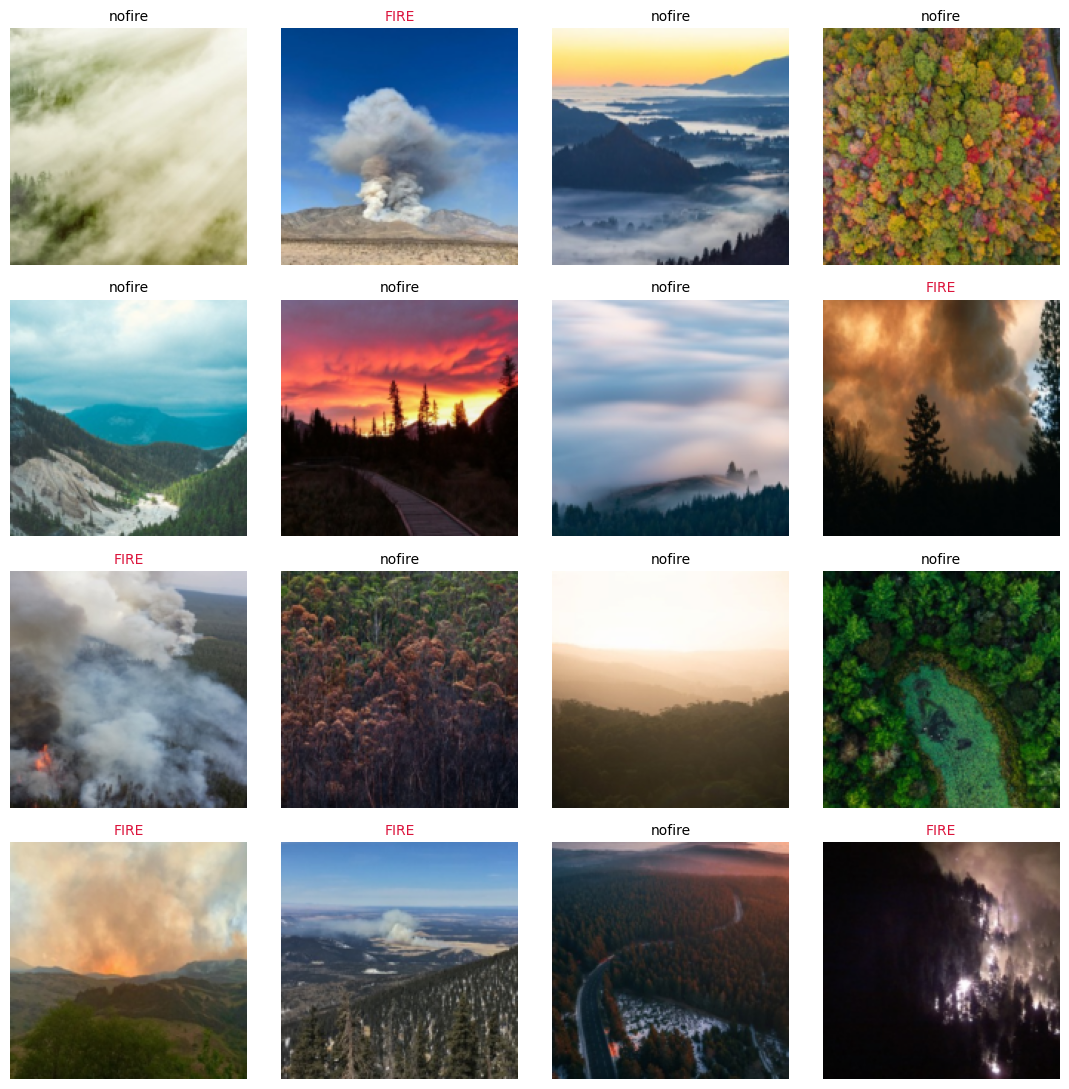

In [6]:
import numpy as np, matplotlib.pyplot as plt

def unnormalize(t):
    x = t.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)   # CHW -> HWC, undo Normalize
    return np.clip(x, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for ax, img, lab in zip(axes.ravel(), xb, yb):
    ax.imshow(unnormalize(img))
    ax.set_title('FIRE' if lab.item() == 1 else 'nofire',
                 color='crimson' if lab.item() == 1 else 'black', fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [7]:
import torch
import torch.nn as nn

class ToyNet(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.head(x)
        return x.squeeze(1)

In [8]:
import torch, torch.nn as nn
import random
from torch.utils.data import Subset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)

meta = pd.read_csv(CSV)
meta = meta[meta.split == 'train'].reset_index(drop=True)

rng = random.Random(0)
idx = (rng.sample(meta.index[meta.cls == 'fire'].tolist(), 25) +
       rng.sample(meta.index[meta.cls == 'nofire'].tolist(), 25))

small_ds = Subset(WildfireDataset(CSV, IMGS, 'train', eval_tf), idx)
small_dl = DataLoader(small_ds, batch_size=25, shuffle=True)
print('fire in subset:', sum(small_ds[i][1].item() for i in range(len(small_ds))), '/ 50')

model     = ToyNet(dropout=0.0).to(DEVICE)      # dropout off for the overfit test
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)


def evaluate(model, loader):
    model.eval()                                # dropout off, BatchNorm uses running stats
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():                       # no autograd graph: faster, less memory
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += ((logits > 0) == (yb > 0.5)).sum().item()
            n += len(yb)
    return total_loss / n, correct / n


for epoch in range(400):
    model.train()
    for xb, yb in small_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    if epoch % 20 == 0 or epoch == 199:
        l, a = evaluate(model, small_dl)
        print(f'epoch {epoch:3d}  loss {l:.4f}  acc {a:.3f}')

fire in subset: 25.0 / 50
epoch   0  loss 0.6559  acc 0.540
epoch  20  loss 0.4266  acc 0.800
epoch  40  loss 0.3149  acc 0.860
epoch  60  loss 0.2864  acc 0.920
epoch  80  loss 0.2233  acc 0.920
epoch 100  loss 0.1916  acc 0.960
epoch 120  loss 0.1660  acc 0.980
epoch 140  loss 0.1488  acc 0.940
epoch 160  loss 0.1627  acc 0.940
epoch 180  loss 0.0992  acc 0.980
epoch 199  loss 0.0879  acc 0.980
epoch 200  loss 0.0872  acc 1.000
epoch 220  loss 0.0767  acc 0.980
epoch 240  loss 0.0565  acc 1.000
epoch 260  loss 0.2015  acc 0.900
epoch 280  loss 0.0973  acc 0.980
epoch 300  loss 0.0843  acc 0.980
epoch 320  loss 0.0601  acc 0.980
epoch 340  loss 0.0368  acc 1.000
epoch 360  loss 0.0540  acc 0.980
epoch 380  loss 0.1762  acc 0.880
